In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

In [2]:
shopifytrends=pd.read_csv("shopify_trending_products_2025.csv")
shopifytrends

,Product_ID,Product_Name,Category,Subcategory,Estimated_Total_Units_Sold_in_2025,Estimated_Revenue_in_2025_USD,Price_Range_USD,Trend_Score,Trend_Source,Notes
0,PROD-2025-0001,Loaded Tea At-Home Beverage Pack,Food & Beverage,Beverages,1651289,4953867.0,$3.0-$4,99.6,TikTok Shop Viral,Verified top seller in 2025 ecommerce reports.
1,PROD-2025-0002,Protein Coffee On-The-Go Energy Drink,Food & Beverage,Beverages,1466551,4399653.0,$3.0-$4,96.9,TikTok Shop Viral,Verified top seller in 2025 ecommerce reports.
2,PROD-2025-0003,Whitening Strips 7-Day Treatment,Beauty & Skincare,Personal Care,953072,10483792.0,$11.0-$16,95.7,TikTok Shop Viral,Verified top seller in 2025 ecommerce reports.
3,PROD-2025-0004,5-1 Full Body Shaver,Beauty & Skincare,Personal Care Gadgets,509346,22920570.0,$45.0-$68,97.5,Shopify Trending List,Verified top seller in 2025 ecommerce reports.
4,PROD-2025-0005,Newborn Training Pants Baby Shorts,Baby,Organic Baby Clothing,835510,12532650.0,$15.0-$22,95.2,Shopify Trending List,Verified top seller in 2025 ecommerce reports.
...,...,...,...,...,...,...,...,...,...,...
995,PROD-2025-0996,Glow Baby Safety Gear Crib,Baby,Baby Safety Gear,295113,43529167.5,$135-$160,92.1,Instagram Shop Popular,Trending based on category growth and social m...
996,PROD-2025-0997,Ergonomic Upcycled Fashion Sponge,Eco-Friendly,Upcycled Fashion,97345,18349532.5,$148-$229,75.6,Google Trends Breakout,Trending based on category growth and social m...
997,PROD-2025-0998,Ultra Accessories Scarf,Fashion,Accessories,88171,5246174.5,$24-$95,88.1,Amazon Best Sellers,Trending based on category growth and social m...
998,PROD-2025-0999,Flex Home Office Decor Diffuser,Home & Garden,Home Office Decor,10488,1284780.0,$95-$150,75.0,Amazon Best Sellers,Trending based on category growth and social m...


In [3]:
shopifytrends.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Product_ID                          1000 non-null   object 
 1   Product_Name                        1000 non-null   object 
 2   Category                            1000 non-null   object 
 3   Subcategory                         1000 non-null   object 
 4   Estimated_Total_Units_Sold_in_2025  1000 non-null   int64  
 5   Estimated_Revenue_in_2025_USD       1000 non-null   float64
 6   Price_Range_USD                     1000 non-null   object 
 7   Trend_Score                         1000 non-null   float64
 8   Trend_Source                        1000 non-null   object 
 9   Notes                               1000 non-null   object 
dtypes: float64(2), int64(1), object(7)
memory usage: 78.3+ KB


In [4]:
shopifytrends.head()

,Product_ID,Product_Name,Category,Subcategory,Estimated_Total_Units_Sold_in_2025,Estimated_Revenue_in_2025_USD,Price_Range_USD,Trend_Score,Trend_Source,Notes
0,PROD-2025-0001,Loaded Tea At-Home Beverage Pack,Food & Beverage,Beverages,1651289,4953867.0,$3.0-$4,99.6,TikTok Shop Viral,Verified top seller in 2025 ecommerce reports.
1,PROD-2025-0002,Protein Coffee On-The-Go Energy Drink,Food & Beverage,Beverages,1466551,4399653.0,$3.0-$4,96.9,TikTok Shop Viral,Verified top seller in 2025 ecommerce reports.
2,PROD-2025-0003,Whitening Strips 7-Day Treatment,Beauty & Skincare,Personal Care,953072,10483792.0,$11.0-$16,95.7,TikTok Shop Viral,Verified top seller in 2025 ecommerce reports.
3,PROD-2025-0004,5-1 Full Body Shaver,Beauty & Skincare,Personal Care Gadgets,509346,22920570.0,$45.0-$68,97.5,Shopify Trending List,Verified top seller in 2025 ecommerce reports.
4,PROD-2025-0005,Newborn Training Pants Baby Shorts,Baby,Organic Baby Clothing,835510,12532650.0,$15.0-$22,95.2,Shopify Trending List,Verified top seller in 2025 ecommerce reports.


In [5]:
shopifytrends.tail()

,Product_ID,Product_Name,Category,Subcategory,Estimated_Total_Units_Sold_in_2025,Estimated_Revenue_in_2025_USD,Price_Range_USD,Trend_Score,Trend_Source,Notes
995,PROD-2025-0996,Glow Baby Safety Gear Crib,Baby,Baby Safety Gear,295113,43529167.5,$135-$160,92.1,Instagram Shop Popular,Trending based on category growth and social m...
996,PROD-2025-0997,Ergonomic Upcycled Fashion Sponge,Eco-Friendly,Upcycled Fashion,97345,18349532.5,$148-$229,75.6,Google Trends Breakout,Trending based on category growth and social m...
997,PROD-2025-0998,Ultra Accessories Scarf,Fashion,Accessories,88171,5246174.5,$24-$95,88.1,Amazon Best Sellers,Trending based on category growth and social m...
998,PROD-2025-0999,Flex Home Office Decor Diffuser,Home & Garden,Home Office Decor,10488,1284780.0,$95-$150,75.0,Amazon Best Sellers,Trending based on category growth and social m...
999,PROD-2025-1000,Pro Educational Toys Stroller,Baby,Educational Toys,46039,874741.0,$16-$22,75.2,Amazon Best Sellers,Trending based on category growth and social m...


In [6]:
shopifytrends.shape

(1000, 10)

In [7]:
shopifytrends.describe()

,Estimated_Total_Units_Sold_in_2025,Estimated_Revenue_in_2025_USD,Trend_Score
count,1.000000e+03,1.000000e+03,1000.000000
mean,9.762182e+04,8.986433e+06,81.677600
std,1.778695e+05,1.187540e+07,6.890711
min,1.014400e+04,1.444905e+05,70.000000
25%,3.469100e+04,3.113328e+06,75.800000
50%,6.283300e+04,5.760511e+06,81.800000
75%,8.801925e+04,9.984228e+06,86.900000
max,2.765107e+06,8.833306e+07,99.600000


In [8]:
shopifytrends.isnull().sum()

Product_ID                            0
Product_Name                          0
Category                              0
Subcategory                           0
Estimated_Total_Units_Sold_in_2025    0
Estimated_Revenue_in_2025_USD         0
Price_Range_USD                       0
Trend_Score                           0
Trend_Source                          0
Notes                                 0
dtype: int64

In [9]:
shopifytrends.groupby("Category") ["Estimated_Revenue_in_2025_USD"].sum().sort_values(ascending=False)

Category
Fitness              1.265127e+09
Pet                  1.121738e+09
Digital Goods        1.093895e+09
Beauty & Skincare    1.048244e+09
Baby                 9.899086e+08
Eco-Friendly         9.851407e+08
Home & Garden        9.686938e+08
Fashion              8.113164e+08
Electronics          6.930159e+08
Food & Beverage      9.353520e+06
Name: Estimated_Revenue_in_2025_USD, dtype: float64

Fitness products generated the highest revenue among all categories, followed closly by pet and Digital Goodds.
This suggests that shopify trending products in 2025 are dominated by lifestyle, emotional spending, and digital scalability martkets.
Food & Beverage had the lowest revenue contribution, indicating either lower dataset representation or lower trnding performance in this category. 

In [10]:
shopifytrends.columns

Index(['Product_ID', 'Product_Name', 'Category', 'Subcategory',
       'Estimated_Total_Units_Sold_in_2025', 'Estimated_Revenue_in_2025_USD',
       'Price_Range_USD', 'Trend_Score', 'Trend_Source', 'Notes'],
      dtype='object')

In [11]:
shopifytrends.groupby("Product_Name")["Estimated_Revenue_in_2025_USD"].sum().sort_values(ascending=False).head(10)


Product_Name
Minimalist Zero-waste Kits Utensils    88333064.0
Organic Biodegradable Products Wrap    84798516.0
Smart Pet Feeder with Camera           83403000.0
Ultra Baby Safety Gear Carrier         81275341.0
Smart Kitchen Gadgets Organizer        80922275.0
Ultra Upcycled Fashion Composter       80593133.0
Pure Recovery Tools Band               80435650.5
Premium SaaS Subscriptions Software    78720480.0
Nano Organic Baby Clothing Stroller    76628447.0
Zen Organic Pet Food Brush             74367653.5
Name: Estimated_Revenue_in_2025_USD, dtype: float64

Top revenu-generating products in the shopify  dataset are dominated by sustainability-focused and pet-related items.
Eco-friendly products such as zero-waste kits and biodegradable wraps rank among the highest in revenue, indicating strong consumer demand for sustainable living solutions. 
Additionally, the pet industry especially smart pet products shows consistently high revenue performance, suggesting growing investment in pet care technology and premium pet products.

In [12]:
shopifytrends[["Trend_Score","Estimated_Revenue_in_2025_USD"]].corr()

,Trend_Score,Estimated_Revenue_in_2025_USD
Trend_Score,1.000000,0.435503
Estimated_Revenue_in_2025_USD,0.435503,1.000000


Analysis shows a moderate positive correlation (0.43) between Trend_Score and Estimated Revenue.
This indicates that while trending products tend to generate higher revenue, trend popularity along does not strongly determines sales performance.
Other factors such as product category, pricing, and market demand likely play a significant role in revenue. 

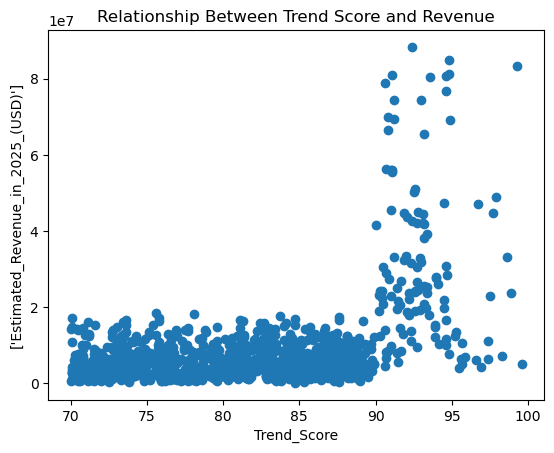

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.scatter(data=shopifytrends, x="Trend_Score", y="Estimated_Revenue_in_2025_USD")
plt.xlabel("Trend_Score")
plt.ylabel(["Estimated_Revenue_in_2025_(USD)"])
plt.title("Relationship Between Trend Score and Revenue")
plt.show()

# Visualization Interpretation
The scatter plot shows a positive relationship between Trend Score and Estimated Revenue.
Products with higher trend scores generally tend to generate more revenue. However, the points are widely dispersed, indicationg that trend scoer alone does not explain revenue performance.
This observation is consistent with the correlation coefficient of 0.43, which suggests a moderate positive relationship between the two variables. 

In [15]:
Trend_threshold=shopifytrends['Trend_Score'].quantile(0.75)
Revenue_threshold=shopifytrends['Estimated_Revenue_in_2025_USD'].quantile(0.75)
opportunities=shopifytrends[(shopifytrends['Trend_Score']>=Trend_threshold)&(shopifytrends['Estimated_Revenue_in_2025_USD']<=Revenue_threshold)]
opportunities[["Product_Name", "Category","Trend_Score","Estimated_Revenue_in_2025_USD"]].sort_values(by="Trend_Score",ascending=False).head(10)

,Product_Name,Category,Trend_Score,Estimated_Revenue_in_2025_USD
0,Loaded Tea At-Home Beverage Pack,Food & Beverage,99.6,4953867.0
9,Healing Tool Tuning Fork Set,Fitness,98.3,7148130.0
11,Electric Cordless Rotary Tool Kit,Home & Garden,97.4,6294360.0
1,Protein Coffee On-The-Go Energy Drink,Food & Beverage,96.9,4399653.0
18,Biodegradable Bamboo Toothbrush 10-Pack,Eco-Friendly,96.6,6191565.0
5,Vintage Crochet Set,Fashion,95.9,6792030.0
19,Digital Planner 2025 Pro Edition,Digital Goods,95.7,5098688.0
6,Kids Sonic Clean Auto-Toothbrush,Baby,95.6,6277000.0
7,Automated Toilet Bowl Cleaner,Home & Garden,95.5,4097784.0
191,Ergonomic Organic Pet Food Leash,Pet,94.8,7806298.5


## Opportunity Analysis: High Trend, Low Revenue Products
This analysis identifies products with strong market interest but relatively low revenue performance.
Products in this group may represent emerging opportunities where demand is growing faster than sales. 
These products could benefit from increased marketing, improved pricing strategies, or expanded distribution to capture untapped renenue potential. 

In [17]:
Revenue_By_Price=shopifytrends.groupby("Price_Range_USD")["Estimated_Revenue_in_2025_USD"].sum()
Revenue_By_Price.sort_values(ascending=False)

Price_Range_USD
$142-$226      88333064.0
$140-$232      84798516.0
$120.0-$180    83403000.0
$145-$226      81275341.0
$127-$216      80922275.0
                  ...    
$14-$52          461010.0
$28-$48          387942.0
$11-$34          312007.5
$20-$29          266290.5
$10-$17          144490.5
Name: Estimated_Revenue_in_2025_USD, Length: 966, dtype: float64

## Revenue Analysis by Price Range
This analysis examines how revenue is distributed across different product price ranges.
Understanding which price segments generate the most revenue can help businesses optimize price strategies and identify attractive market segments. 
The results highlight whether low-,mid-,or high-priced products contributes most to overall revenue.

In [18]:
Avg_Trend_by_Category=shopifytrends.groupby("Category")["Trend_Score"].mean()
Avg_Trend_by_Category.sort_values(ascending=False)

Category
Food & Beverage      98.250000
Fitness              82.312409
Beauty & Skincare    82.018033
Baby                 81.948246
Eco-Friendly         81.712903
Fashion              81.639604
Home & Garden        81.633654
Electronics          81.181081
Pet                  81.174757
Digital Goods        80.965487
Name: Trend_Score, dtype: float64

## Average Trend Score by Category
This analysis measures the average trend score for each product category.
Trend Score reflects consumer interest and market momentum. Categories with higher average trend score may be better positioned for future growth. 
Comparing trend scores across categories helps identify where emerging demand is concentrated.


## Category Trend Insights
This shows that Food & Beverage, Fitness, and Beauty & Skincare are the strongest performing categories in terms of trend momentum. 
These categories reflect lifestyle-driven consumer behavior and emerging demand patterns.
In contrast, Electronics, Pet and Digital Goods show lower trend scores, suggesting either market saturation or slower growth in consumer interest within the dataset period.


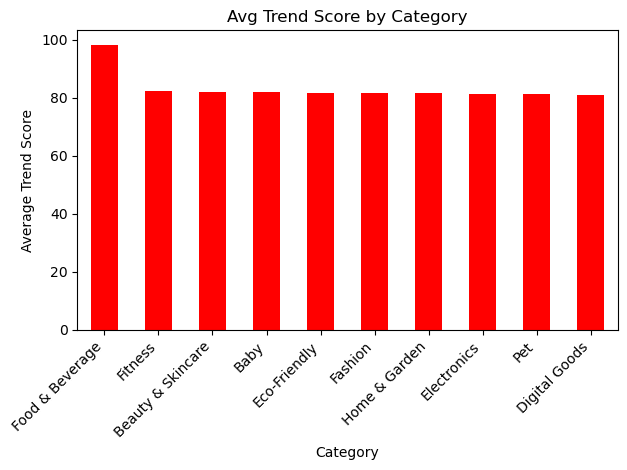

In [20]:
import matplotlib.pyplot as plt
Category_Trend=shopifytrends.groupby("Category")["Trend_Score"].mean().sort_values(ascending=False)
plt.figure()
Category_Trend.plot(kind="bar",color="red")
plt.title("Avg Trend Score by Category")
plt.xlabel("Category")
plt.ylabel("Average Trend Score")
plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.show()

In [21]:
df=shopifytrends.copy()
print(shopifytrends.columns)
shopifytrends["Trend_Rank"]=shopifytrends['Trend_Score']. rank(pct=True)
shopifytrends["Revenue_Rank"]=shopifytrends['Estimated_Revenue_in_2025_USD'].rank(pct=True)
mask=(shopifytrends['Trend_Rank']>=0.75)&(shopifytrends['Revenue_Rank']<=0.25)
result=shopifytrends[mask]
cols=["Product_Name","Category","Trend_Score","Estimated_Revenue_in_2025_USD"]
result=result.loc[:,cols]
result.head(10)

Index(['Product_ID', 'Product_Name', 'Category', 'Subcategory',
       'Estimated_Total_Units_Sold_in_2025', 'Estimated_Revenue_in_2025_USD',
       'Price_Range_USD', 'Trend_Score', 'Trend_Source', 'Notes'],
      dtype='object')


,Product_Name,Category,Trend_Score,Estimated_Revenue_in_2025_USD
51,Minimalist Eco-friendly Cleaning Desk,Home & Garden,87.6,2516864.0
56,Pro Personal Care Gadgets Brush,Beauty & Skincare,88.1,2680587.5
57,Wireless Accessories Belt,Fashion,88.2,2069347.5
108,Flex Upcycled Fashion Kit,Eco-Friendly,87.2,1170081.0
158,Swift Digital Planners Bundle,Digital Goods,88.8,3048189.0
189,Nano Eco-friendly Diapers Crib,Baby,87.1,1864032.0
289,Organic Korean Skincare Dryer,Beauty & Skincare,88.9,2049245.0
316,Sustainable Womenswear Leggings,Fashion,88.4,1900762.5
345,Glow Organic Makeup Oil,Beauty & Skincare,87.5,3008608.0
373,Aura Korean Skincare Brush,Beauty & Skincare,86.9,1268931.0


## Hidden Opportunity Products
This analysis identifies products with high trend scores but relatively low revenue performance, highlighting potential under-monietized demand. 
These products repersent missed revenue opportunities where consumer interest is strong, but monetization strategies may be underdeveloped. 
Targeting these products with improved pricing, marketing, or visibility could significantly increased revenue efficiency. 